In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import ast 

## 1ere section : analyse du dataset (arxiv)

à l'issue de ce notebook nous aurons l'occasion de parcourir ce dataset, de traiter l'étendu des données le constituant (données textuelles précisèment), les transformer et appliquer un problème de ML dessus

le dataset : arXiv paper abstract dataset for building multi-label text classifiers. // https://www.kaggle.com/datasets/spsayakpaul/arxiv-paper-abstracts/data 


In [6]:
def charger_dataset(chemin_dataset : str = "./data/arxiv_data_210930-054931.csv"):
    #chemin par défaut renvoie au dataset avec abstract 
    return pd.read_csv(chemin_dataset)

df = charger_dataset()
df.describe()

,terms,titles,abstracts
count,56181,56181,56181
unique,3402,41105,41115
top,['cs.CV'],Deep Reinforcement Learning: An Overview,Mesh is a powerful data structure for 3D shape...
freq,18719,7,7


### Analyse des données du dataset 

Nombre total de documents : 56181
Colonnes disponibles : ['terms', 'titles', 'abstracts', 'longueur_categories', 'longueur_abstract']
Valeurs manquantes par colonne :
terms                  0
titles                 0
abstracts              0
longueur_categories    0
longueur_abstract      0
dtype: int64
Nombre de catégories uniques : 3402
Distribution des catégories (top 10) :
terms
['cs.CV']                        18719
['cs.LG', 'stat.ML']              5431
['cs.LG']                         2871
['cs.CV', 'cs.LG']                2170
['cs.LG', 'cs.AI']                1783
['cs.LG', 'cs.AI', 'stat.ML']     1512
['stat.ML', 'cs.LG']              1497
['cs.CV', 'cs.AI']                 997
['cs.CV', 'cs.LG', 'eess.IV']      891
['cs.CV', 'eess.IV']               801
Name: count, dtype: int64
nombre réel de catégories unique :  1177  => catégories : 
  {'I.5.0, I.2.0', 'H.3.1; I.2.6; I.2.7', '37M10, 68T07, 68T05, 68T37, 82C32', 'A.1; I.2.6; I.2.8; J.4', '68U15, 68T50', 'B.7.2', 'cond-mat

Text(0, 0.5, 'Nombre de documents')

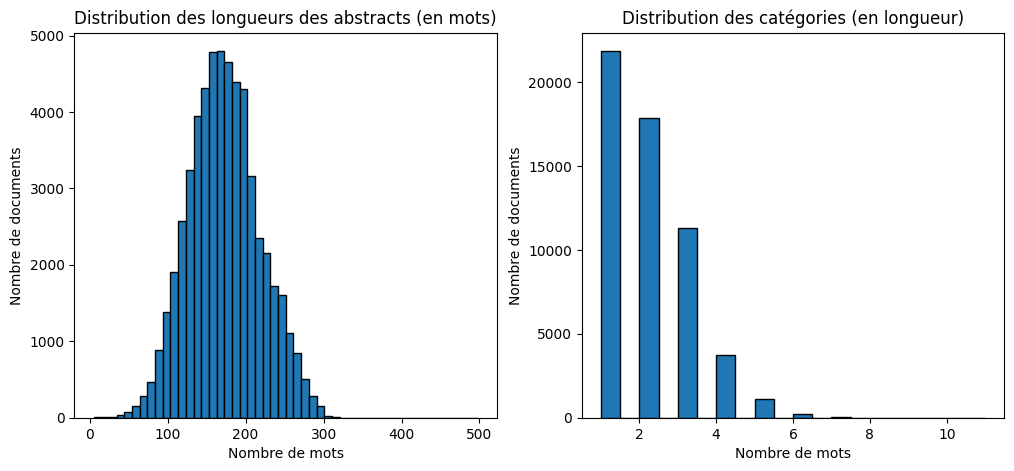

In [22]:
num_documents = df.shape[0]
print(f"Nombre total de documents : {num_documents}")

colonnes = df.columns.tolist()
print(f"Colonnes disponibles : {colonnes}")

valeurs_manquantes = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes)

colonne_categories = 'terms'  
colonne_abstract = 'abstracts'  

### Region 1 : analyse des catégories : terms 



num_categories = df[colonne_categories].nunique()
print(f"Nombre de catégories uniques : {num_categories}")

distribution_categories = df[colonne_categories].value_counts()
print("Distribution des catégories (top 10) :")
print(distribution_categories.head(10))



ensemble_categories = set()
for categories_str in df[colonne_categories]:
    #convertir la chaine et liste 
    categories_list = ast.literal_eval(categories_str) 
    ensemble_categories.update(categories_list)
        

print("nombre réel de catégories unique : ",len(ensemble_categories)," => catégories : \n ",ensemble_categories)

df["longueur_categories"] = df[colonne_categories].apply(lambda x : len(ast.literal_eval(x)))
moyenne_labels_par_doc = df["longueur_categories"].mean()
max_labels_par_doc = df["longueur_categories"].max()
print(f"Nombre moyen de labels par document : {moyenne_labels_par_doc}")
print(f"Nombre maximum de labels par document : {max_labels_par_doc}")


## 2 : analyse des abstracts 

df["longueur_abstract"] = df[colonne_abstract].astype(str).str.split().apply(len)
longueur_moyenne = df["longueur_abstract"].mean()
longueur_mediane = df["longueur_abstract"].median()
longueur_min = df["longueur_abstract"].min()
longueur_max = df["longueur_abstract"].max()
print(f"Longueur moyenne des abstracts (mots) : {longueur_moyenne}")
print(f"Longueur médiane des abstracts (mots) : {longueur_mediane}")
print(f"Longueur minimale : {longueur_min}, maximale : {longueur_max}")

fig, graphiques = plt.subplots(1, 2, figsize=(12, 5))
graphiques[0].hist(df["longueur_abstract"], bins=50, edgecolor='black')
graphiques[0].set_title('Distribution des longueurs des abstracts (en mots)')
graphiques[0].set_xlabel('Nombre de mots')
graphiques[0].set_ylabel('Nombre de documents')

graphiques[1].hist(df["longueur_categories"], bins=20, edgecolor='black')
graphiques[1].set_title('Distribution des catégories (en longueur)')
graphiques[1].set_xlabel('Nombre de mots')
graphiques[1].set_ylabel('Nombre de documents')

première analyse à chaud : difficultés quant au nombre de catégories distinctes 1177 => à voir si on en garde que les top-k plus fréquentes ? 

MultiLabelClassification ? avec seuillage sur une sigmoide à la fin (ou garder softmax sur une seule sortie seuleemnt parmi plusieurs labels ???) 

Stratégie : oneVsRest/ All , classe CS et le reste .... et ensuite physique et le reste (y compris CS ...) ???